In [80]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.interpolate import interp1d
from tqdm import tqdm

In [81]:
df = pd.read_csv("paired_simulation_labels_combined.csv")

In [82]:
# ==========================================
# 1. Fast Loader
# ==========================================

def load_corrected_lightcurve(folder_path):
    """Robust file loader that safely ignores text headers."""
    dat_files = glob.glob(os.path.join(folder_path, "*_driftcorrected.dat"))
    if not dat_files:
        dat_files = glob.glob(os.path.join(folder_path, "*.dat"))
        
    if dat_files:
        data_rows = []
        with open(dat_files[0], "r") as f:
            for line in f:
                parts = line.split()
                if not parts:
                    continue
                try:
                    data_rows.append([float(p) for p in parts])
                except ValueError:
                    # Silently ignore header strings
                    continue
        data = np.asarray(data_rows, dtype=float)
        if data.ndim == 2 and data.shape[1] >= 2:
            return data[:, 0], data[:, 1]

    return None, None


In [ ]:
# ==========================================
# 2. Pre-baking and Plotting Routine
# ==========================================

def build_prebaked_dataset(df, max_length=50_000, save_path="cnn_dataset.pt", plot_samples=3):
    print("Initializing pre-baking process...")
    
    # Storage arrays
    all_fluxes = []
    all_labels = [] # Will now store [is_flare, is_transit]
    all_amps = []   # New: Flare amplitudes
    all_radii = []  # New: Planet radii
    all_ids = []
    plot_data = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Interpolating Lightcurves"):
        sys_id = row['system_id']
        label_val = int(row['anomaly_class'])
        
        time, flux = load_corrected_lightcurve(f"outputs/{sys_id}/")
        
        if time is None or len(time) < 100:
            continue
            
        # --- 1. Label & Metadata Extraction ---
        # Convert anomaly_class (0,1,2,3) to multi-label [flare_bool, transit_bool]
        is_flare = 1.0 if label_val in [1, 3] else 0.0
        is_transit = 1.0 if label_val in [2, 3] else 0.0
        
        # Safely extract physical parameters (fill NaNs with 0.0)
        amp = row.get('flare_amplitude', 0.0)
        amp = 0.0 if pd.isna(amp) else float(amp)
        
        rad = row.get('transit_radius_earth', 0.0)
        rad = 0.0 if pd.isna(rad) else float(rad)

        # --- 2. Clean and median-center ---
        finite = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[finite], flux[finite]
        
        order = np.argsort(time)
        time, flux = time[order], flux[order]
        flux = flux - np.nanmedian(flux)
        
        # --- 3. Normalize time strictly between 0 and 1 ---
        t_min, t_max = time.min(), time.max()
        t_norm = (time - t_min) / (t_max - t_min)
        
        # --- 4. Uniform grid interpolation ---
        t_uniform = np.linspace(0, 1, max_length)
        f_interp = interp1d(t_norm, flux, kind='linear')
        uniform_flux = f_interp(t_uniform)
        
        # Visualization sample storage
        if len(plot_data) < plot_samples and np.random.rand() > 0.8:
            plot_data.append({
                'sys_id': sys_id,
                'class': {0: "Neither", 1: "Flare", 2: "Transit", 3: "Both"}[label_val],
                'orig_t': t_norm,
                'orig_f': flux,
                'interp_t': t_uniform,
                'interp_f': uniform_flux
            })
            
        all_fluxes.append(uniform_flux)
        all_labels.append([is_flare, is_transit]) # Store as 2D
        all_amps.append(amp)
        all_radii.append(rad)
        all_ids.append(sys_id)

    # Convert to PyTorch Tensors
    print(f"\nFinished processing. Converting {len(all_fluxes)} arrays to PyTorch Tensors...")
    
    X_tensor = torch.tensor(np.array(all_fluxes), dtype=torch.float32).unsqueeze(1)
    y_tensor = torch.tensor(np.array(all_labels), dtype=torch.float32) # Float32 for BCEWithLogitsLoss
    amps_tensor = torch.tensor(np.array(all_amps), dtype=torch.float32)
    radii_tensor = torch.tensor(np.array(all_radii), dtype=torch.float32)
    
    # Save EVERYTHING to disk
    torch.save({
        'X': X_tensor,
        'y': y_tensor,
        'amps': amps_tensor,
        'radii': radii_tensor,
        'ids': all_ids
    }, save_path)
    
    print(f"Successfully saved {X_tensor.shape[0]} lightcurves to '{save_path}'")
    print(f"Tensor Shape: {X_tensor.shape} | Labels Shape: {y_tensor.shape}")
    
    # Generate the QA Plots
    if plot_data:
        fig, axes = plt.subplots(len(plot_data), 1, figsize=(15, 4 * len(plot_data)), sharex=True)
        if len(plot_data) == 1:
            axes = [axes]
            
        for ax, data in zip(axes, plot_data):
            # Plot original raw data as scattered gray dots
            ax.scatter(data['orig_t'], data['orig_f'], color='gray', s=5, alpha=0.5, label='Original Data')
            # Plot interpolated data as a sharp red line
            ax.plot(data['interp_t'], data['interp_f'], color='red', linewidth=1.5, alpha=0.8, label=f'Interpolated ({max_length} pts)')
            
            ax.set_title(f"System: {data['sys_id']} | Class: {data['class']}")
            ax.set_ylabel("Median-Centered Flux")
            ax.legend(loc="upper right")
            
        axes[-1].set_xlabel("Normalized Time (0 to 1)")
        plt.tight_layout()
        plt.show()



Initializing pre-baking process...


Interpolating Lightcurves: 100%|██████████| 2000/2000 [29:38<00:00,  1.12it/s]



Finished processing. Converting 1485 arrays to PyTorch Tensors...
Successfully saved 1485 lightcurves to 'cnn_dataset.pt'
Tensor Shape: torch.Size([1485, 1, 50000]) | Labels Shape: torch.Size([1485, 2])


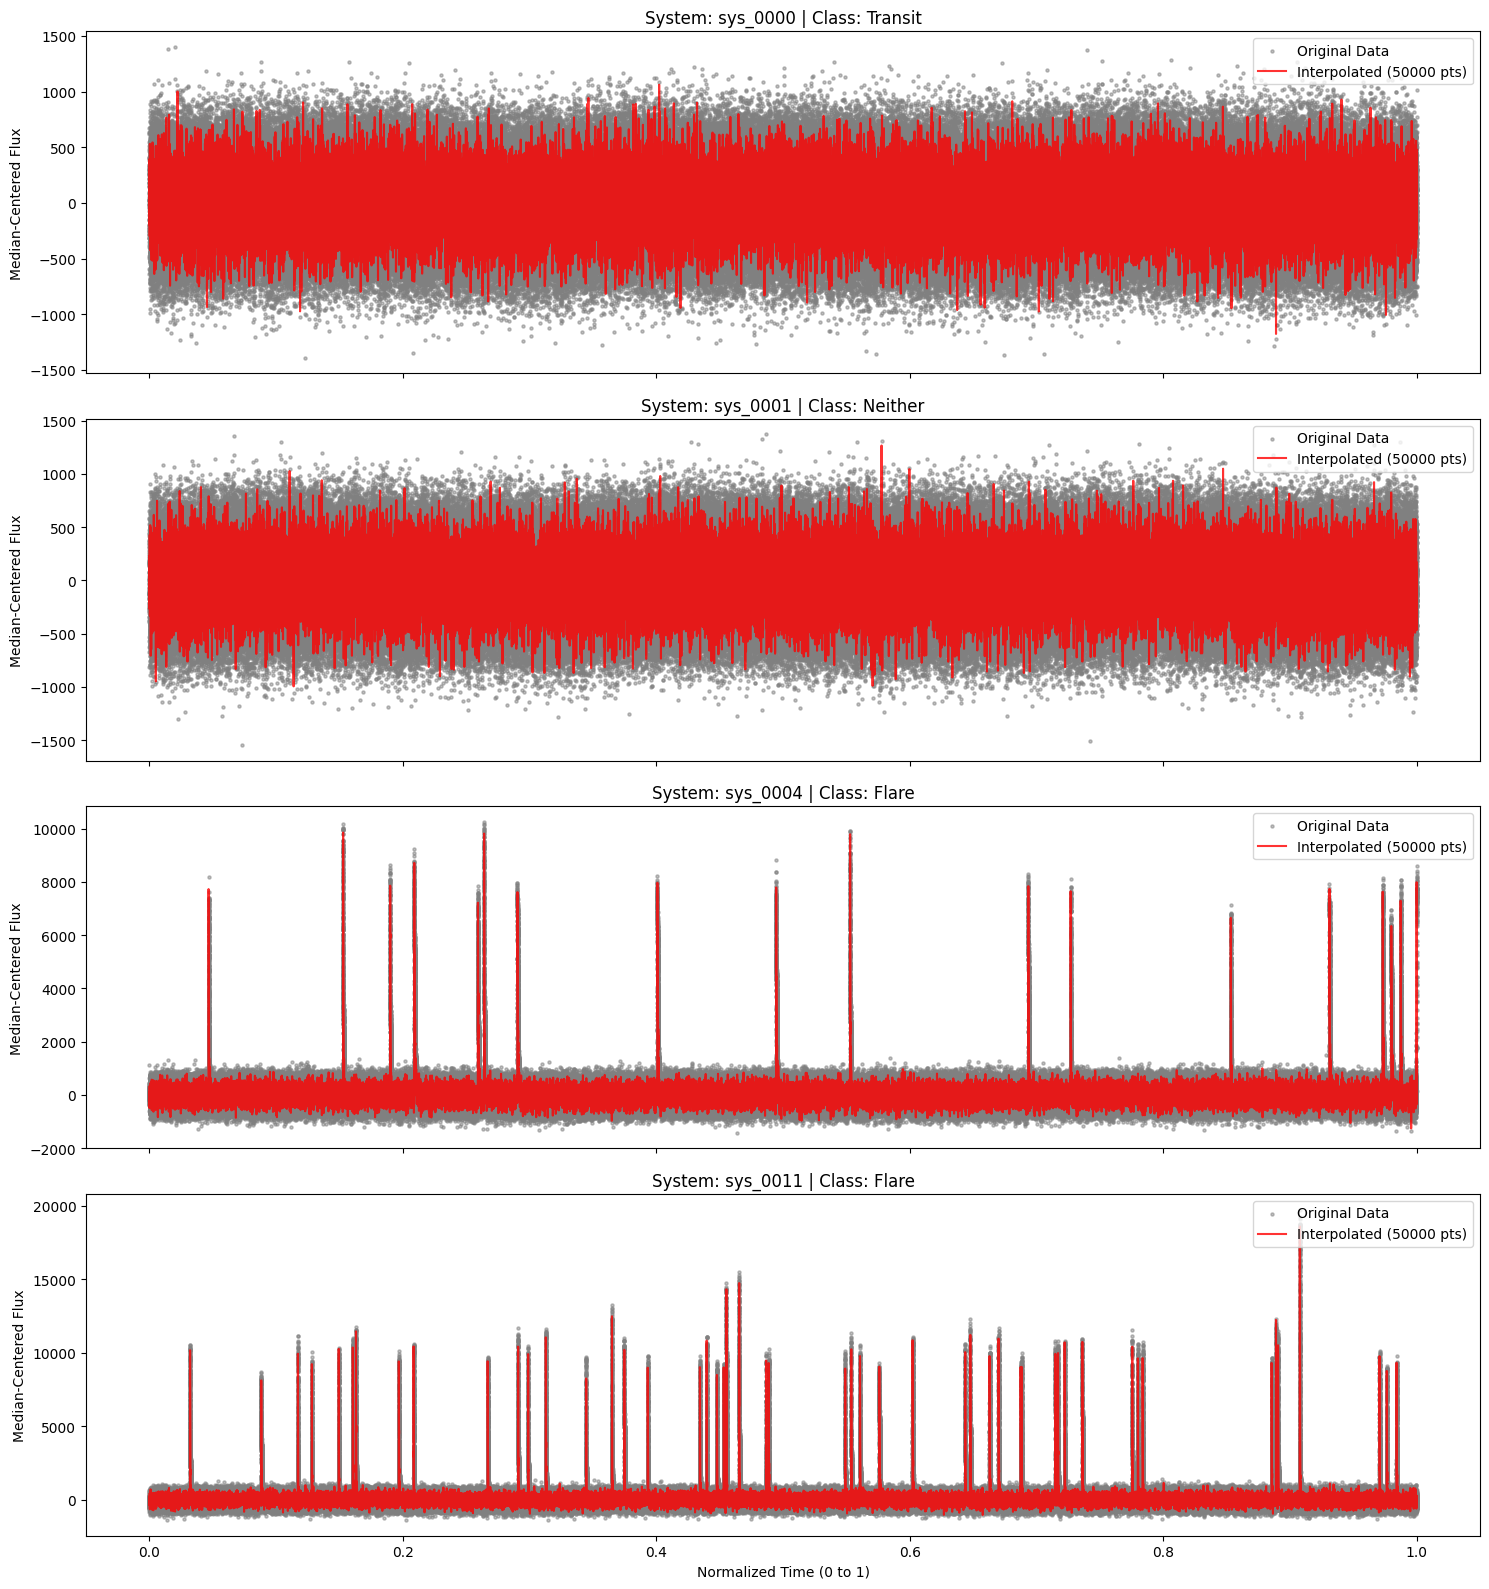

In [87]:
build_prebaked_dataset(df, max_length=50_000, save_path="cnn_dataset.pt", plot_samples=4)

In [97]:
from torch.utils.data import Dataset, DataLoader, random_split

class PhysicalLightCurveDataset(Dataset):
    def __init__(self, pt_file_path):
        data = torch.load(pt_file_path)
        self.X = data['X']
        self.y = data['y']
        self.amps = data['amps']
        self.radii = data['radii']
        self.ids = data['ids']

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Return 5 items: Input, Label, Flare Amp, Planet Radius, System ID
        return self.X[idx], self.y[idx], self.amps[idx], self.radii[idx], self.ids[idx]

def get_dataloaders(save_path, batch_size=32, train_split=0.8):
    dataset = PhysicalLightCurveDataset(save_path)
    
    train_size = int(train_split * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    # Don't shuffle validation so predictions align cleanly during inference
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader

In [107]:
import torch
import torch.nn as nn

class LightCurveCNN(nn.Module):
    def __init__(self, input_length=50_000):
        super().__init__()
        
        self.convs = nn.Sequential(
            # Layer 1: Kernel 15 = ~2 hours of data. 
            # Wide enough to see transit slopes, narrow enough to spot a 4-pt flare.
            # Removed stride=2 to prevent skipping flare spikes.
            nn.Conv1d(1, 16, kernel_size=15, padding=7), 
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(4), # Array length: 50k -> 12.5k
            
            # Layer 2: Kernel 11 = ~1.5 hours. 
            nn.Conv1d(16, 32, kernel_size=11, padding=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4), # Array length: 12.5k -> 3,125
            
            # Layer 3: Kernel 7
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4), # Array length: 3,125 -> 781
            
            # Layer 4: Kernel 5 (Feature depth enhancement)
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            # Global Pooling: Forces translation invariance.
            # Output is strictly (Batch, 128, 16)
            nn.AdaptiveMaxPool1d(16) 
        )
        
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_length)
            flat_size = self.convs(dummy).numel()
        print(f"Flattened size: {flat_size}") # Should be 2048

        self.shared_fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU()
        )
        
        self.head_flare   = nn.Linear(64, 1)
        self.head_transit = nn.Linear(64, 1)

    def forward(self, x):
        x = self.convs(x)
        x = x.flatten(1)
        x = self.shared_fc(x)
        return self.head_flare(x).squeeze(1), self.head_transit(x).squeeze(1)

In [108]:
from torch.utils.data import TensorDataset, DataLoader

def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            
        # Validation
        model.eval()
        # Add evaluation logic here (e.g., accuracy calculation)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

In [109]:
import time
import torch
import torch.nn.functional as F

FLARE_THRESH   = 0.5
TRANSIT_THRESH = 0.5

def transit_loss(logits, targets, radii):
    """
    BCE, with a step up above 3 R_earth.
    """
    base_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    # weights = torch.where(radii >= 3.0,
    #                       torch.ones_like(radii),        # large planet: full weight
    #                       0.3 * torch.ones_like(radii))  # small planet: downweighted
    return (base_loss).mean()

def flare_loss(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets)

# ==========================================
# 2. Training Pipeline
# ==========================================
def run_training_pipeline(save_path="cnn_dataset.pt", epochs=30): # Updated default to 30
    start_total = time.time()

    print("--- 1. Loading Prebaked Data ---")
    train_loader, val_loader = get_dataloaders(save_path)

    model = LightCurveCNN(input_length=50_000)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    print(f"--- 2. Starting Training on {device} ---")
    print(f"Dataset size: {len(train_loader.dataset)} samples")

    optimizer = torch.optim.Adam(model.parameters(), lr=4e-4, weight_decay=1e-4)

    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0

        # --- Training Loop ---
        for i, (X, y, batch_amps, batch_radii, sys_ids) in enumerate(train_loader):
            X, y = X.to(device), y.to(device)
            batch_radii = batch_radii.to(device)

            optimizer.zero_grad()
            flare_logits, transit_logits = model(X)
            loss = flare_loss(flare_logits, y[:, 0]) \
                + transit_loss(transit_logits, y[:, 1], batch_radii)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            
            if i % 10 == 0:
                print(f"  Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

        # --- Validation Loop ---
        model.eval()
        val_loss = 0.0
        total = 0
        stats = {"flare":   {"tp":0,"fp":0,"fn":0,"tn":0},
                 "transit": {"tp":0,"fp":0,"fn":0,"tn":0}}

        with torch.no_grad():
            # CRITICAL: Unpack all 5 variables here too to match the new dataloader
            for X, y, batch_amps, batch_radii, sys_ids in val_loader:
                X, y = X.to(device), y.to(device)
                flare_logits, transit_logits = model(X)

                # Keep standard BCE for val_loss so you have a stable, unweighted metric to track
                val_loss += F.binary_cross_entropy_with_logits(flare_logits,   y[:, 0]).item() \
                          + F.binary_cross_entropy_with_logits(transit_logits, y[:, 1]).item()

                flare_pred   = (flare_logits.sigmoid()   > FLARE_THRESH).float()
                transit_pred = (transit_logits.sigmoid() > TRANSIT_THRESH).float()
                total += len(y)

                for name, pred, true in [("flare",   flare_pred,   y[:, 0]),
                                          ("transit", transit_pred, y[:, 1])]:
                    stats[name]["tp"] += ((pred == 1) & (true == 1)).sum().item()
                    stats[name]["fp"] += ((pred == 1) & (true == 0)).sum().item()
                    stats[name]["fn"] += ((pred == 0) & (true == 1)).sum().item()
                    stats[name]["tn"] += ((pred == 0) & (true == 0)).sum().item()

        epoch_time = time.time() - epoch_start
        print(f"\nEpoch {epoch+1}/{epochs} | {epoch_time:.1f}s | "
              f"Train Loss: {running_loss/len(train_loader):.4f} | "
              f"Val Loss: {val_loss/len(val_loader):.4f}")
        for name, s in stats.items():
            acc  = 100 * (s["tp"] + s["tn"]) / total
            prec = s["tp"] / (s["tp"] + s["fp"]) if (s["tp"] + s["fp"]) > 0 else 0
            rec  = s["tp"] / (s["tp"] + s["fn"]) if (s["tp"] + s["fn"]) > 0 else 0
            f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
            print(f"  {name:8s}: Acc={acc:.1f}%  Prec={prec:.2f}  Rec={rec:.2f}  F1={f1:.2f}  "
                  f"TP={s['tp']} FP={s['fp']} FN={s['fn']} TN={s['tn']}")

    torch.save(model.state_dict(), "cnn_model.pt")
    print(f"\nModel saved to cnn_model.pt")
    print(f"Total time: {(time.time()-start_total)/60:.2f} minutes")
    return model, val_loader, device

# Run it
model, val_loader, device = run_training_pipeline(epochs=15)

--- 1. Loading Prebaked Data ---
Flattened size: 2048
--- 2. Starting Training on cpu ---
Dataset size: 1188 samples
  Batch 0/38 | Loss: 1.4457
  Batch 10/38 | Loss: 1.2344
  Batch 20/38 | Loss: 1.2334
  Batch 30/38 | Loss: 1.0758

Epoch 1/15 | 24.4s | Train Loss: 1.2923 | Val Loss: 1.1954
  flare   : Acc=80.5%  Prec=0.97  Rec=0.61  F1=0.75  TP=86 FP=3 FN=55 TN=153
  transit : Acc=50.5%  Prec=0.00  Rec=0.00  F1=0.00  TP=0 FP=0 FN=147 TN=150
  Batch 0/38 | Loss: 1.1788
  Batch 10/38 | Loss: 1.2293
  Batch 20/38 | Loss: 1.1039
  Batch 30/38 | Loss: 1.0244

Epoch 2/15 | 25.9s | Train Loss: 1.1479 | Val Loss: 1.0401
  flare   : Acc=85.9%  Prec=0.99  Rec=0.71  F1=0.83  TP=100 FP=1 FN=41 TN=155
  transit : Acc=54.2%  Prec=0.54  Rec=0.50  F1=0.52  TP=74 FP=63 FN=73 TN=87
  Batch 0/38 | Loss: 1.1752
  Batch 10/38 | Loss: 1.0155
  Batch 20/38 | Loss: 0.8392
  Batch 30/38 | Loss: 1.0736

Epoch 3/15 | 23.8s | Train Loss: 1.1062 | Val Loss: 0.9749
  flare   : Acc=87.5%  Prec=1.00  Rec=0.74  F1=0.

In [110]:
model.eval()
data = torch.load("cnn_dataset.pt", map_location="cpu")
X, y = data['X'], data['y']  # y is (1485, 2): col0=has_flare, col1=has_transit

has_transit = y[:, 1].bool()  # second column
print(f"n_transit: {has_transit.sum()}, n_no_transit: {(~has_transit).sum()}")

with torch.no_grad():
    _, transit_logits = model(X)

probs = transit_logits.sigmoid()
print(f"Transit systems     — mean prob: {probs[has_transit].mean():.3f}  std: {probs[has_transit].std():.3f}")
print(f"No-transit systems  — mean prob: {probs[~has_transit].mean():.3f}  std: {probs[~has_transit].std():.3f}")

n_transit: 742, n_no_transit: 743
Transit systems     — mean prob: 0.365  std: 0.273
No-transit systems  — mean prob: 0.203  std: 0.088


In [111]:
torch.save({
    'model_state_dict': model.state_dict(),
    'input_length': 50_000,
    'num_classes': 4,
}, "cnn_checkpoint.pt")
print("Saved to cnn_checkpoint.pt")

Saved to cnn_checkpoint.pt


In [114]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

def generate_cnn_analysis_df(model, dataset, df_meta, device, flare_thresh=0.5, transit_thresh=0.35): # Adjusted transit_thresh
    model.eval()
    results = []
    class_map = {0: 'neither', 1: 'flare', 2: 'transit', 3: 'both'}
    
    with torch.no_grad():
        for i in range(len(dataset)):
            data = dataset[i]
            X = data[0].unsqueeze(0).to(device)
            y = data[1]
            
            # --- THE FIX: Correctly locate sys_id based on dataset structure ---
            if len(data) == 5:
                sys_id = data[4] # Updated PyTorch Dataset (X, y, amp, rad, id)
            elif len(data) == 3:
                sys_id = data[2] # Old format (X, y, id)
            else:
                sys_id = df_meta.iloc[i]['system_id']
            
            flare_logits, transit_logits = model(X)
            
            pred_flare = int(flare_logits.sigmoid().item() > flare_thresh)
            pred_transit = int(transit_logits.sigmoid().item() > transit_thresh)
            
            if pred_flare and pred_transit: pred_class = 'both'
            elif pred_flare:                pred_class = 'flare'
            elif pred_transit:              pred_class = 'transit'
            else:                           pred_class = 'neither'
            
            true_flare, true_transit = y[0].item(), y[1].item()
            if true_flare and true_transit: true_int = 3
            elif true_flare:                true_int = 1
            elif true_transit:              true_int = 2
            else:                           true_int = 0
            
            results.append({
                'system_id': sys_id,
                'true_event_class': class_map[true_int],
                'pred_event_class': pred_class,
                'flare_prob': flare_logits.sigmoid().item(),
                'transit_prob': transit_logits.sigmoid().item()
            })
            
    df_preds = pd.DataFrame(results)
    full_analysis = pd.merge(df_preds, df_meta, on='system_id', how='left')
    return full_analysis

# Rerun the inference to get the newly fixed dataframe
val_dataset = val_loader.dataset
full_analysis = generate_cnn_analysis_df(model, val_dataset, df, device, transit_thresh=0.28) # Notice the 0.28 threshold from our histogram logic!

/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding



--- Flare Detection Stats per Bin ---
                           prob  count
bin                                   
(504.608, 757.563]     0.333333     15
(757.563, 1064.128]    0.714286     14
(1064.128, 1595.953]   0.857143     14
(1595.953, 2336.114]   0.785714     14
(2336.114, 3895.367]   1.000000     14
(3895.367, 5736.713]   1.000000     14
(5736.713, 8274.442]   1.000000     14
(8274.442, 9903.328]   0.928571     14
(9903.328, 13386.87]   1.000000     14
(13386.87, 18742.708]  0.928571     14


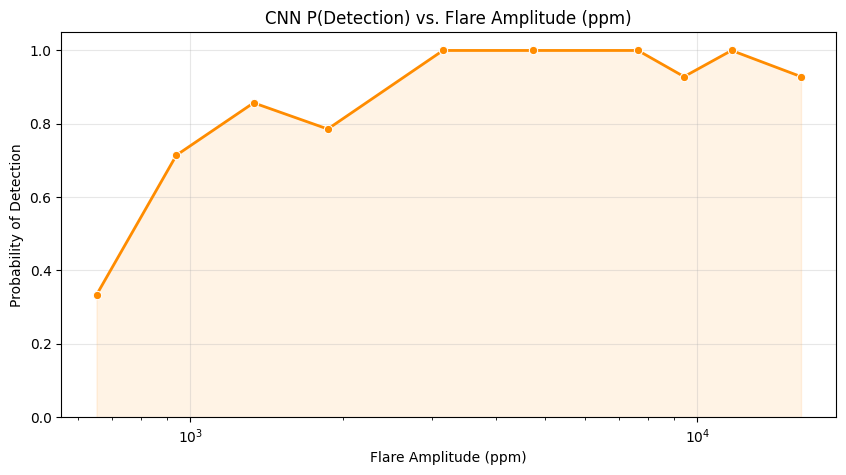


--- Transit Detection Stats per Bin ---
                     prob  count
bin                             
(0.152, 0.478]   0.133333     15
(0.478, 0.855]   0.133333     15
(0.855, 1.134]   0.428571     14
(1.134, 1.473]   0.200000     15
(1.473, 1.995]   0.200000     15
(1.995, 2.432]   0.500000     14
(2.432, 3.047]   0.933333     15
(3.047, 4.297]   1.000000     14
(4.297, 6.507]   0.933333     15
(6.507, 20.677]  0.933333     15


/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


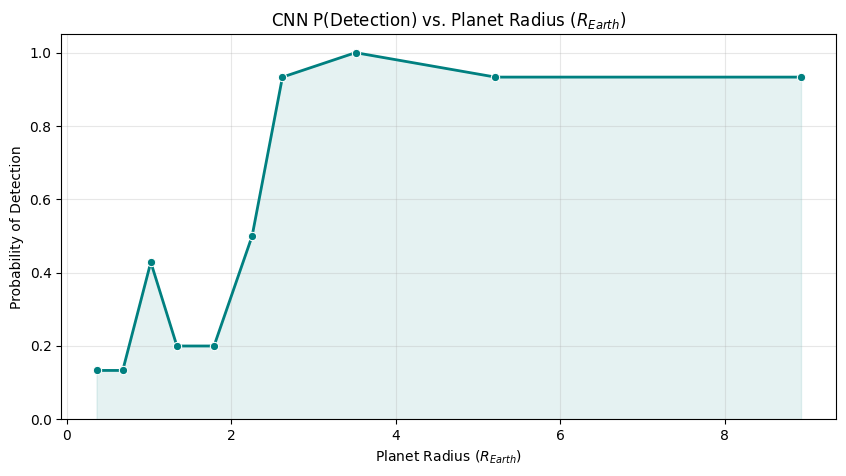

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_detection_probability(df_analysis, feature_col, label, target_class='transit', bins=10, log_x=False):
    valid_classes = [target_class, 'both']
    
    # Filter for systems that have the event AND drop any rows missing the physical parameter
    subset = df_analysis[df_analysis['true_event_class'].isin(valid_classes)].copy()
    subset = subset.dropna(subset=[feature_col]) 
    
    if subset.empty:
        print(f"No {target_class} systems found in this dataset slice with valid {feature_col}.")
        return
        
    subset['is_detected'] = subset['pred_event_class'].isin(valid_classes).astype(int)
    
    # Try qcut (equal sizes), fallback to cut (equal spacing), allow duplicate edges
    try:
        subset['bin'] = pd.qcut(subset[feature_col], q=bins, duplicates='drop')
    except ValueError:
        subset['bin'] = pd.cut(subset[feature_col], bins=bins)
    
    bin_stats = subset.groupby('bin', observed=True).agg(
        prob=('is_detected', 'mean'),
        midpoint=(feature_col, 'median'),
        count=('is_detected', 'count')
    ).dropna()

    plt.figure(figsize=(10, 5))
    color = 'darkorange' if target_class == 'flare' else 'teal'
    
    sns.lineplot(data=bin_stats, x='midpoint', y='prob', marker='o', linewidth=2, color=color)
    plt.fill_between(bin_stats['midpoint'], 0, bin_stats['prob'], alpha=0.1, color=color)

    print(f"\n--- {target_class.capitalize()} Detection Stats per Bin ---")
    print(bin_stats[['prob', 'count']])
    
    plt.title(f"CNN P(Detection) vs. {label}")
    plt.xlabel(label)
    
    # Toggle log scale based on the parameter
    if log_x:
        plt.xscale("log")
        
    plt.ylabel("Probability of Detection")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.show()

# ==========================================
# Run the Analysis (Validation Data Only)
# ==========================================

# 1. Plot the Flare Sensitivity (Log Scale)
plot_detection_probability(
    df_analysis=full_analysis, 
    feature_col='flare_amplitude', 
    label="Flare Amplitude (ppm)", 
    target_class='flare', 
    bins=10,
    log_x=True  # Use log scale for massive amplitude variations
)

# 2. Plot the Transit Sensitivity (Linear Scale)
plot_detection_probability(
    df_analysis=full_analysis, 
    feature_col='transit_radius_earth', 
    label="Planet Radius ($R_{Earth}$)", 
    target_class='transit', 
    bins=10,
    log_x=False # Linear scale is usually better for radius
)